#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
library(Seurat)
library(dplyr)
library(tidyverse)
library(reshape2)
library(ggplot2)

Warning message:
“程辑包‘Seurat’是用R版本4.3.3 来建造的”
载入需要的程辑包：SeuratObject

Warning message:
“程辑包‘SeuratObject’是用R版本4.3.3 来建造的”
载入需要的程辑包：sp

Warning message:
“程辑包‘sp’是用R版本4.3.2 来建造的”

载入程辑包：‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“程辑包‘dplyr’是用R版本4.3.2 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“程辑包‘tidyverse’是用R版本4.3.3 来建造的”
Warning message:
“程辑包‘readr’是用R版本4.3.3 来建造的”
Warning message:
“程辑包‘stringr’是用R版本4.3.2 来建造的”
Warning message:
“程辑包‘forcats’是用R版本4.3.3 来建造的”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyvers

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
mC <- read.csv("../../../04.data/02.metainfo/01.Young_Mouse/TSO-joint.mC_QC_stat.young.csv")

In [ ]:
hmC <- read.csv("../../../04.data/02.metainfo/01.Young_Mouse/TSO-joint.hmC_QC_stat.young.csv")

In [ ]:
DNA <- rbind(hmC,mC)

In [ ]:
head(DNA);dim(DNA)

,SampleID,Plate_ID,Sample_ID_without_barcode,Unique_ID,Species,Datatype,Library,Region,Brain.Region,Batch,⋯,fullpuc19_mCG_R_pre,lambda_CGn_pre,lambda_mCG_R_pre,cla1_CGn_pre,cla1_mCG_R_pre,QC,class_label,subclass_label,three_class_label,Neuron_non_neuron
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AACCAGAG,P49_Male_Hippo_TSO_joint5mC_plate1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1,P49_Male_Hippo_TSO_plate1.AACCAGAG,mm10,TSO-joint-RNA,hmC,Hippo,Hippo,230912-0914-0915,⋯,0.0181,479305,0.0129,6791,0.9959,1,IT-ET Glut,CA1-ProS Glut,Exc,Neuron
2,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACACC,P49_Male_Hippo_TSO_joint5mC_plate1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1,P49_Male_Hippo_TSO_plate1.AAGACACC,mm10,TSO-joint-RNA,hmC,Hippo,Hippo,230912-0914-0915,⋯,0.0181,58843,0.0196,5302,0.9915,1,IT-ET Glut,SUB-ProS Glut,Exc,Neuron
3,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACCGT,P49_Male_Hippo_TSO_joint5mC_plate1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1,P49_Male_Hippo_TSO_plate1.AAGACCGT,mm10,TSO-joint-RNA,hmC,Hippo,Hippo,230912-0914-0915,⋯,0.0215,661098,0.0202,7664,0.9970,1,IT-ET Glut,CA1-ProS Glut,Exc,Neuron
4,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACCTTG,P49_Male_Hippo_TSO_joint5mC_plate1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1,P49_Male_Hippo_TSO_plate1.AGACCTTG,mm10,TSO-joint-RNA,hmC,Hippo,Hippo,230912-0914-0915,⋯,0.0207,572775,0.0155,6627,0.9947,1,IT-ET Glut,SUB-ProS Glut,Exc,Neuron
5,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACGCTA,P49_Male_Hippo_TSO_joint5mC_plate1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1,P49_Male_Hippo_TSO_plate1.AGACGCTA,mm10,TSO-joint-RNA,hmC,Hippo,Hippo,230912-0914-0915,⋯,0.0166,512406,0.0121,6908,0.9980,1,IT-ET Glut,SUB-ProS Glut,Exc,Neuron
6,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGCCTATC,P49_Male_Hippo_TSO_joint5mC_plate1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1,P49_Male_Hippo_TSO_plate1.AGCCTATC,mm10,TSO-joint-RNA,hmC,Hippo,Hippo,230912-0914-0915,⋯,0.0191,505233,0.0140,6320,0.9978,1,CTX-CGE GABA,Sncg Gaba,Inh,Neuron


[1] 95424    60

In [3]:
colnames(DNA)

[1] "SampleID"                  "Plate_ID"                 
 [3] "Sample_ID_without_barcode" "Unique_ID"                
 [5] "Species"                   "Datatype"                 
 [7] "Library"                   "Region"                   
 [9] "Brain.Region"              "Batch"                    
[11] "spatial_type"              "Age"                      
[13] "Total_reads"               "Clean_reads"              
[15] "Filter_reads_r"            "Filter_base_r"            
[17] "raw_depth"                 "clean_depth"              
[19] "Aligned_Reads"             "Align_rate"               
[21] "COVERAGE"                  "chrM_readsN"              
[23] "Dup_rate"                  "Mean_Insertion_size"      
[25] "Depth_after_align"         "lambda_aligned"           
[27] "fullpuc19_aligned"         "cla1_aligned"             
[29] "dna_CpG_Cov"               "dna_CGn"                  
[31] "dna_mCG_R"                 "dna_mCHG_R"               
[33] "dna_mCHH_R"                "fullpuc19_CGn_after"      
[35] "fullpuc19_mCG_R_after"     "lambda_CGn_after"         
[37] "lambda_mCG_R_after"        "cla1_CGn_after"           
[39] "cla1_mCG_R_after"          "dna_reads_num"            
[41] "rna_reads_num"             "dna_reads_ratio"          
[43] "rna_reads_ratio"           "dna_reads_coverage"       
[45] "rna_CpG_Cov"               "rna_CGn"                  
[47] "rna_mCG_R"                 "rna_mCHG_R"               
[49] "rna_mCHH_R"                "fullpuc19_CGn_pre"        
[51] "fullpuc19_mCG_R_pre"       "lambda_CGn_pre"           
[53] "lambda_mCG_R_pre"          "cla1_CGn_pre"             
[55] "cla1_mCG_R_pre"            "QC"                       
[57] "class_label"               "subclass_label"           
[59] "three_class_label"         "Neuron_non_neuron"

In [ ]:
metadata_all <- read.csv("../../../04.data/02.metainfo/01.Young_Mouse/RNA_DNA_match_name_QC_class_label.csv")

In [5]:
head(metadata_all);dim(metadata_all)

,RNA,Unique_ID_match,hmC,mC,RNA_filter4_QC,hmC_QC,mC_QC,total_QC,class_label,subclass_label,three_class_label
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AACCAGAG,P49_Male_Hippo_TSO_plate1.AACCAGAG,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AACCAGAG,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5hmC_plate1.AACCAGAG,1,1,0,0,IT-ET Glut,CA1-ProS Glut,Exc
2,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AAGACACC,P49_Male_Hippo_TSO_plate1.AAGACACC,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACACC,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5hmC_plate1.AAGACACC,1,1,0,0,IT-ET Glut,SUB-ProS Glut,Exc
3,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AAGACCGT,P49_Male_Hippo_TSO_plate1.AAGACCGT,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACCGT,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5hmC_plate1.AAGACCGT,1,1,0,0,IT-ET Glut,CA1-ProS Glut,Exc
4,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AGACCTTG,P49_Male_Hippo_TSO_plate1.AGACCTTG,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACCTTG,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5hmC_plate1.AGACCTTG,1,1,0,0,IT-ET Glut,SUB-ProS Glut,Exc
5,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AGACGCTA,P49_Male_Hippo_TSO_plate1.AGACGCTA,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACGCTA,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5hmC_plate1.AGACGCTA,1,1,0,0,IT-ET Glut,SUB-ProS Glut,Exc
6,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_RNA_plate1.AGCCTATC,P49_Male_Hippo_TSO_plate1.AGCCTATC,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGCCTATC,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5hmC_plate1.AGCCTATC,1,1,0,0,CTX-CGE GABA,Sncg Gaba,Inh


[1] 47712    11

In [6]:
metadata_all_filter <- metadata_all[metadata_all$total_QC == 1,]
head(metadata_all_filter);dim(metadata_all_filter)

,RNA,Unique_ID_match,hmC,mC,RNA_filter4_QC,hmC_QC,mC_QC,total_QC,class_label,subclass_label,three_class_label
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1153,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_RNA_plate1.AACCAGAG,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AACCAGAG,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AACCAGAG,1,1,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc
1154,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_RNA_plate1.AAGACACC,P49_Male_LeftCortex_TSO_plate1.AAGACACC,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACACC,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AAGACACC,1,1,1,1,IT-ET Glut,CLA-EPd-CTX Car3 Glut,Exc
1155,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_RNA_plate1.AAGACCGT,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACCGT,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AAGACCGT,1,1,1,1,IT-ET Glut,L4 RSP-ACA Glut,Exc
1156,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_RNA_plate1.AGACCTTG,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACCTTG,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGACCTTG,1,1,1,1,NP-CT-L6b Glut,L6 CT CTX Glut,Exc
1157,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_RNA_plate1.AGACGCTA,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACGCTA,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGACGCTA,1,1,1,1,IT-ET Glut,L4/5 IT CTX Glut,Exc
1158,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_RNA_plate1.AGCCTATC,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGCCTATC,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGCCTATC,1,1,1,1,IT-ET Glut,L2/3 IT CTX Glut,Exc


[1] 44608    11

In [7]:
library(dplyr)

In [8]:
DNA_filter <- DNA %>% dplyr::select(SampleID,dna_mCG_R,subclass_label)
head(DNA_filter);dim(DNA_filter)

,SampleID,dna_mCG_R,subclass_label
,<chr>,<dbl>,<chr>
1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AACCAGAG,0.2443,CA1-ProS Glut
2,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACACC,0.2655,SUB-ProS Glut
3,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACCGT,0.2385,CA1-ProS Glut
4,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACCTTG,0.2541,SUB-ProS Glut
5,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACGCTA,0.2477,SUB-ProS Glut
6,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGCCTATC,0.2490,Sncg Gaba


[1] 95424     3

In [9]:
grep("joint5mC",DNA_filter$SampleID,value = T) %>% length()
grep("joint5mC",DNA_filter$SampleID,value = T) %>% head()

[1] 47712

[1] "P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AACCAGAG"
[2] "P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACACC"
[3] "P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACCGT"
[4] "P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACCTTG"
[5] "P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACGCTA"
[6] "P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGCCTATC"

In [10]:
mCpG <- DNA_filter[DNA_filter$SampleID %in% grep("joint5mC",DNA_filter$SampleID,value = T),]
hmCpG <- DNA_filter[DNA_filter$SampleID %in% grep("joint5hmC",DNA_filter$SampleID,value = T),]

In [11]:
head(mCpG);dim(mCpG)
head(hmCpG);dim(hmCpG)

,SampleID,dna_mCG_R,subclass_label
,<chr>,<dbl>,<chr>
1,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AACCAGAG,0.2443,CA1-ProS Glut
2,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACACC,0.2655,SUB-ProS Glut
3,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AAGACCGT,0.2385,CA1-ProS Glut
4,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACCTTG,0.2541,SUB-ProS Glut
5,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGACGCTA,0.2477,SUB-ProS Glut
6,P49_Male_230905Mouse1_Hippo_EXP230908_TSO_joint5mC_plate1.AGCCTATC,0.2490,Sncg Gaba


[1] 47712     3

,SampleID,dna_mCG_R,subclass_label
,<chr>,<dbl>,<chr>
1153,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AACCAGAG,0.229890,L4/5 IT CTX Glut
1154,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACACC,0.265841,CLA-EPd-CTX Car3 Glut
1155,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACCGT,0.303104,L4 RSP-ACA Glut
1156,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACCTTG,0.228072,L6 CT CTX Glut
1157,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACGCTA,0.220399,L4/5 IT CTX Glut
1158,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGCCTATC,0.274885,L2/3 IT CTX Glut


[1] 47712     3

In [ ]:
table(mCpG$SampleID %in% metadata_all_filter$mC_ID)


FALSE  TRUE 
 3104 44608 

In [ ]:
table(hmCpG$SampleID %in% metadata_all_filter$hmC_ID)


FALSE  TRUE 
 3104 44608 

In [ ]:
mCpG_filter <- mCpG[mCpG$SampleID %in% metadata_all_filter$mC_ID,]
hmCpG_filter <- hmCpG[hmCpG$SampleID %in% metadata_all_filter$hmC_ID,]

In [15]:
head(mCpG_filter);dim(mCpG_filter)
head(hmCpG_filter);dim(hmCpG_filter)

,SampleID,dna_mCG_R,subclass_label
,<chr>,<dbl>,<chr>
48865,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AACCAGAG,0.787052,L4/5 IT CTX Glut
48866,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AAGACACC,0.806602,CLA-EPd-CTX Car3 Glut
48867,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AAGACCGT,0.797892,L4 RSP-ACA Glut
48868,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGACCTTG,0.789026,L6 CT CTX Glut
48869,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGACGCTA,0.764934,L4/5 IT CTX Glut
48870,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGCCTATC,0.806215,L2/3 IT CTX Glut


[1] 44608     3

,SampleID,dna_mCG_R,subclass_label
,<chr>,<dbl>,<chr>
1153,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AACCAGAG,0.229890,L4/5 IT CTX Glut
1154,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACACC,0.265841,CLA-EPd-CTX Car3 Glut
1155,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACCGT,0.303104,L4 RSP-ACA Glut
1156,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACCTTG,0.228072,L6 CT CTX Glut
1157,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACGCTA,0.220399,L4/5 IT CTX Glut
1158,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGCCTATC,0.274885,L2/3 IT CTX Glut


[1] 44608     3

In [16]:
length(unique(mCpG_filter$subclass_label))
length(unique(hmCpG_filter$subclass_label))

[1] 30

[1] 30

In [17]:
unique(mCpG_filter$subclass_label)

[1] "L4/5 IT CTX Glut"      "CLA-EPd-CTX Car3 Glut" "L4 RSP-ACA Glut"      
 [4] "L6 CT CTX Glut"        "L2/3 IT CTX Glut"      "L5 IT CTX Glut"       
 [7] "Astro-TE NN"           "L5 ET CTX Glut"        "Microglia NN"         
[10] "Oligo NN"              "STR D1 Gaba"           "CA3 Glut"             
[13] "Pvalb Gaba"            "Sncg Gaba"             "Lamp5 Gaba"           
[16] "Sst Gaba"              "ACB-BST-FS D1 Gaba"    "OPC NN"               
[19] "DG Glut"               "L5 NP CTX Glut"        "SUB-ProS Glut"        
[22] "OB-STR-CTX Inh IMN"    "L2/3 IT RSP Glut"      "OEC NN"               
[25] "CA1-ProS Glut"         "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[28] "OB Eomes Ms4a15 Glut"  "OB Dopa-Gaba"          "STR D2 Gaba"

In [ ]:
mCpG_filter$Unique_ID <- metadata_all_filter$Unique_ID_match[match(mCpG_filter$SampleID,metadata_all_filter$mC_ID)]
hmCpG_filter$Unique_ID <- metadata_all_filter$Unique_ID_match[match(hmCpG_filter$SampleID,metadata_all_filter$hmC_ID)]

In [19]:
head(mCpG_filter);dim(mCpG_filter)
head(hmCpG_filter);dim(hmCpG_filter)

,SampleID,dna_mCG_R,subclass_label,Unique_ID
,<chr>,<dbl>,<chr>,<chr>
48865,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AACCAGAG,0.787052,L4/5 IT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AACCAGAG
48866,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AAGACACC,0.806602,CLA-EPd-CTX Car3 Glut,P49_Male_LeftCortex_TSO_plate1.AAGACACC
48867,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AAGACCGT,0.797892,L4 RSP-ACA Glut,P49_Male_LeftCortex_TSO_plate1.AAGACCGT
48868,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGACCTTG,0.789026,L6 CT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AGACCTTG
48869,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGACGCTA,0.764934,L4/5 IT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AGACGCTA
48870,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5mC_plate1.AGCCTATC,0.806215,L2/3 IT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AGCCTATC


[1] 44608     4

,SampleID,dna_mCG_R,subclass_label,Unique_ID
,<chr>,<dbl>,<chr>,<chr>
1153,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AACCAGAG,0.229890,L4/5 IT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AACCAGAG
1154,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACACC,0.265841,CLA-EPd-CTX Car3 Glut,P49_Male_LeftCortex_TSO_plate1.AAGACACC
1155,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AAGACCGT,0.303104,L4 RSP-ACA Glut,P49_Male_LeftCortex_TSO_plate1.AAGACCGT
1156,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACCTTG,0.228072,L6 CT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AGACCTTG
1157,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGACGCTA,0.220399,L4/5 IT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AGACGCTA
1158,P49_Male_240416Mouses_LeftCortex_EXP240419_TSO_joint5hmC_plate1.AGCCTATC,0.274885,L2/3 IT CTX Glut,P49_Male_LeftCortex_TSO_plate1.AGCCTATC


[1] 44608     4

In [20]:
table(mCpG_filter$Unique_ID %in% hmCpG_filter$Unique_ID)
table(hmCpG_filter$Unique_ID %in% mCpG_filter$Unique_ID)


 TRUE 
44608 


 TRUE 
44608 

In [21]:
mCpG_filter <- mCpG_filter %>% dplyr::select(Unique_ID,subclass_label,dna_mCG_R)
colnames(mCpG_filter) <- c("Unique_ID","subclass_label","mCpG")
head(mCpG_filter);dim(mCpG_filter)

,Unique_ID,subclass_label,mCpG
,<chr>,<chr>,<dbl>
48865,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,L4/5 IT CTX Glut,0.787052
48866,P49_Male_LeftCortex_TSO_plate1.AAGACACC,CLA-EPd-CTX Car3 Glut,0.806602
48867,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,L4 RSP-ACA Glut,0.797892
48868,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,L6 CT CTX Glut,0.789026
48869,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,L4/5 IT CTX Glut,0.764934
48870,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215


[1] 44608     3

In [22]:
hmCpG_filter <- hmCpG_filter %>% dplyr::select(Unique_ID,dna_mCG_R)
colnames(hmCpG_filter) <- c("Unique_ID","hmCpG")
head(hmCpG_filter);dim(hmCpG_filter)

,Unique_ID,hmCpG
,<chr>,<dbl>
1153,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,0.229890
1154,P49_Male_LeftCortex_TSO_plate1.AAGACACC,0.265841
1155,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,0.303104
1156,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,0.228072
1157,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,0.220399
1158,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,0.274885


[1] 44608     2

In [23]:
mC_hmC_final <- merge(mCpG_filter,hmCpG_filter,by = "Unique_ID")
head(mC_hmC_final);dim(mC_hmC_final)

,Unique_ID,subclass_label,mCpG,hmCpG
,<chr>,<chr>,<dbl>,<dbl>
1,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,L4/5 IT CTX Glut,0.787052,0.229890
2,P49_Male_LeftCortex_TSO_plate1.AAGACACC,CLA-EPd-CTX Car3 Glut,0.806602,0.265841
3,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,L4 RSP-ACA Glut,0.797892,0.303104
4,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,L6 CT CTX Glut,0.789026,0.228072
5,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,L4/5 IT CTX Glut,0.764934,0.220399
6,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215,0.274885


[1] 44608     4

In [24]:
mC_hmC_final$true_CpG <- mC_hmC_final$mCpG - mC_hmC_final$hmCpG

In [25]:
head(mC_hmC_final);dim(mC_hmC_final)

,Unique_ID,subclass_label,mCpG,hmCpG,true_CpG
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,L4/5 IT CTX Glut,0.787052,0.229890,0.557162
2,P49_Male_LeftCortex_TSO_plate1.AAGACACC,CLA-EPd-CTX Car3 Glut,0.806602,0.265841,0.540761
3,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,L4 RSP-ACA Glut,0.797892,0.303104,0.494788
4,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,L6 CT CTX Glut,0.789026,0.228072,0.560954
5,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,L4/5 IT CTX Glut,0.764934,0.220399,0.544535
6,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215,0.274885,0.531330


[1] 44608     5

In [ ]:
hmCH <- read.delim(sprintf("%s/merged_5hmCH.txt",indir),sep = ' ',header = F)
head(hmCH);dim(hmCH)

,V1,V2,V3,V4
,<chr>,<chr>,<chr>,<chr>
1,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5hmC/allc_P56_Male_231211Mouse1_Olfactory_EXP231218_TSO_joint5hmC_plate37.GTCCTTGA.mm10.dna.tsv.gz,185464,36783536,0.00504204
2,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5hmC/allc_P56_Male_230920Mouse1_SuperficialCortex_EXP231113_TSO_joint5hmC_plate25.CAACACAG.mm10.dna.tsv.gz,129557,21744320,0.0059582
3,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5hmC/allc_P56_Male_231211Mouse1_Hippo_EXP231225_TSO_joint5hmC_plate25.TCTACGCA.mm10.dna.tsv.gz,123686,23158268,0.0053409
4,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5hmC/allc_P56_Male_231204Mouse1_SuperficialCortex_EXP240111_TSO_joint5hmC_plate86.GGTATAGG.mm10.dna.tsv.gz,160508,26364314,0.00608808
5,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5hmC/allc_P49_Male_240416Mouses_RightHippo_EXP240419_TSO_joint5hmC_plate1.CTCGACTT.mm10.dna.tsv.gz,462236,99679080,0.00463724
6,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5hmC/allc_P56_Male_231127Mouse1_SuperficialCortex_EXP231207_TSO_joint5hmC_plate67.GGACATCA.mm10.dna.tsv.gz,206572,26501341,0.00779478


[1] 48116     4

In [27]:
hmCH$V1 <- gsub(".mm10.dna.tsv.gz","",gsub(".*allc_","",hmCH$V1))

In [ ]:
head(hmCH);dim(hmCH)
table(hmCH$V1 %in% metadata_all_filter$hmC_ID)

,V1,V2,V3,V4
,<chr>,<chr>,<chr>,<chr>
1,P56_Male_231211Mouse1_Olfactory_EXP231218_TSO_joint5hmC_plate37.GTCCTTGA,185464,36783536,0.00504204
2,P56_Male_230920Mouse1_SuperficialCortex_EXP231113_TSO_joint5hmC_plate25.CAACACAG,129557,21744320,0.0059582
3,P56_Male_231211Mouse1_Hippo_EXP231225_TSO_joint5hmC_plate25.TCTACGCA,123686,23158268,0.0053409
4,P56_Male_231204Mouse1_SuperficialCortex_EXP240111_TSO_joint5hmC_plate86.GGTATAGG,160508,26364314,0.00608808
5,P49_Male_240416Mouses_RightHippo_EXP240419_TSO_joint5hmC_plate1.CTCGACTT,462236,99679080,0.00463724
6,P56_Male_231127Mouse1_SuperficialCortex_EXP231207_TSO_joint5hmC_plate67.GGACATCA,206572,26501341,0.00779478


[1] 48116     4


FALSE  TRUE 
 3508 44608 

In [ ]:
hmCH <- hmCH[hmCH$V1 %in% metadata_all_filter$hmC_ID,]

In [ ]:
mCH <- read.delim(sprintf("%s/merged_5mCH.txt",indir),sep = ' ',header = F)
head(mCH);dim(mCH)

,V1,V2,V3,V4
,<chr>,<chr>,<chr>,<chr>
1,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5mC/allc_P56_Male_231204Mouse1_SuperficialCortex_EXP240110_TSO_joint5mC_plate81.CGAGAGAA.mm10.dna.tsv.gz,123771,5402973,0.0229079
2,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5mC/allc_P49_Male_240416Mouses_RightCortex_EXP240420_TSO_joint5mC_plate4.CGTATCTC.mm10.dna.tsv.gz,2172633,80924012,0.0268478
3,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5mC/allc_P56_Male_231017Mouse1_SuperficialCortex_EXP231023_TSO_joint5mC_plate3.CTCGACTT.mm10.dna.tsv.gz,1212494,39399692,0.0307742
4,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5mC/allc_P49_Male_240416Mouses_RightCortex_EXP240421_TSO_joint5mC_plate6.TATGGCAC.mm10.dna.tsv.gz,1303305,59737870,0.0218171
5,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5mC/allc_P56_Male_231204Mouse1_DeepCortex_EXP240118_TSO_joint5mC_plate90.AAGACCGT.mm10.dna.tsv.gz,918073,49249610,0.0186412
6,/share/analysisdata/Methyl/workflow/TSO_HT/Datadir/Mouse_Brain/allc_data/TSO-joint-RNA/5mC/allc_P56_Male_231211Mouse1_Hippo_EXP231222_TSO_joint5mC_plate16.AGACGCTA.mm10.dna.tsv.gz,1724339,57536172,0.0299697


[1] 48116     4

In [31]:
mCH$V1 <- gsub(".mm10.dna.tsv.gz","",gsub(".*allc_","",mCH$V1))

In [32]:
head(mCH);dim(mCH)

,V1,V2,V3,V4
,<chr>,<chr>,<chr>,<chr>
1,P56_Male_231204Mouse1_SuperficialCortex_EXP240110_TSO_joint5mC_plate81.CGAGAGAA,123771,5402973,0.0229079
2,P49_Male_240416Mouses_RightCortex_EXP240420_TSO_joint5mC_plate4.CGTATCTC,2172633,80924012,0.0268478
3,P56_Male_231017Mouse1_SuperficialCortex_EXP231023_TSO_joint5mC_plate3.CTCGACTT,1212494,39399692,0.0307742
4,P49_Male_240416Mouses_RightCortex_EXP240421_TSO_joint5mC_plate6.TATGGCAC,1303305,59737870,0.0218171
5,P56_Male_231204Mouse1_DeepCortex_EXP240118_TSO_joint5mC_plate90.AAGACCGT,918073,49249610,0.0186412
6,P56_Male_231211Mouse1_Hippo_EXP231222_TSO_joint5mC_plate16.AGACGCTA,1724339,57536172,0.0299697


[1] 48116     4

In [ ]:
table(mCH$V1 %in% metadata_all_filter$mC_ID)


FALSE  TRUE 
 3508 44608 

In [ ]:
mCH <- mCH[mCH$V1 %in% metadata_all_filter$mC_ID,]

In [35]:
head(mC_hmC_final);dim(mC_hmC_final)

,Unique_ID,subclass_label,mCpG,hmCpG,true_CpG
,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,L4/5 IT CTX Glut,0.787052,0.229890,0.557162
2,P49_Male_LeftCortex_TSO_plate1.AAGACACC,CLA-EPd-CTX Car3 Glut,0.806602,0.265841,0.540761
3,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,L4 RSP-ACA Glut,0.797892,0.303104,0.494788
4,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,L6 CT CTX Glut,0.789026,0.228072,0.560954
5,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,L4/5 IT CTX Glut,0.764934,0.220399,0.544535
6,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215,0.274885,0.531330


[1] 44608     5

In [ ]:
hmCH$Unique_ID <- metadata_all_filter$Unique_ID_match[match(hmCH$V1,metadata_all_filter$hmC_ID)]
mCH$Unique_ID <- metadata_all_filter$Unique_ID_match[match(mCH$V1,metadata_all_filter$mC_ID)]

In [37]:
head(hmCH);dim(hmCH)
head(mCH);dim(mCH)

,V1,V2,V3,V4,Unique_ID
,<chr>,<chr>,<chr>,<chr>,<chr>
1,P56_Male_231211Mouse1_Olfactory_EXP231218_TSO_joint5hmC_plate37.GTCCTTGA,185464,36783536,0.00504204,P56_Male_Olfactory_TSO_plate37.GTCCTTGA
3,P56_Male_231211Mouse1_Hippo_EXP231225_TSO_joint5hmC_plate25.TCTACGCA,123686,23158268,0.0053409,P56_Male_Hippo_TSO_plate25.TCTACGCA
4,P56_Male_231204Mouse1_SuperficialCortex_EXP240111_TSO_joint5hmC_plate86.GGTATAGG,160508,26364314,0.00608808,P56_Male_SuperficialCortex_TSO_plate86.GGTATAGG
5,P49_Male_240416Mouses_RightHippo_EXP240419_TSO_joint5hmC_plate1.CTCGACTT,462236,99679080,0.00463724,P49_Male_RightHippo_TSO_plate1.CTCGACTT
6,P56_Male_231127Mouse1_SuperficialCortex_EXP231207_TSO_joint5hmC_plate67.GGACATCA,206572,26501341,0.00779478,P56_Male_SuperficialCortex_TSO_plate67.GGACATCA
7,P49_Male_240416Mouses_LeftHippo_EXP240425_TSO_joint5hmC_plate7.GTCATCGT,193759,36734512,0.00527458,P49_Male_LeftHippo_TSO_plate7.GTCATCGT


[1] 44608     5

,V1,V2,V3,V4,Unique_ID
,<chr>,<chr>,<chr>,<chr>,<chr>
1,P56_Male_231204Mouse1_SuperficialCortex_EXP240110_TSO_joint5mC_plate81.CGAGAGAA,123771,5402973,0.0229079,P56_Male_SuperficialCortex_TSO_plate81.CGAGAGAA
2,P49_Male_240416Mouses_RightCortex_EXP240420_TSO_joint5mC_plate4.CGTATCTC,2172633,80924012,0.0268478,P49_Male_RightCortex_TSO_plate4.CGTATCTC
3,P56_Male_231017Mouse1_SuperficialCortex_EXP231023_TSO_joint5mC_plate3.CTCGACTT,1212494,39399692,0.0307742,P56_Male_SuperficialCortex_TSO_plate3.CTCGACTT
4,P49_Male_240416Mouses_RightCortex_EXP240421_TSO_joint5mC_plate6.TATGGCAC,1303305,59737870,0.0218171,P49_Male_RightCortex_TSO_plate6.TATGGCAC
5,P56_Male_231204Mouse1_DeepCortex_EXP240118_TSO_joint5mC_plate90.AAGACCGT,918073,49249610,0.0186412,P56_Male_DeepCortex_TSO_plate90.AAGACCGT
6,P56_Male_231211Mouse1_Hippo_EXP231222_TSO_joint5mC_plate16.AGACGCTA,1724339,57536172,0.0299697,P56_Male_Hippo_TSO_plate16.AGACGCTA


[1] 44608     5

In [38]:
hmCH <- hmCH %>% dplyr::select(Unique_ID,V4)
colnames(hmCH) <- c("Unique_ID","hmCH")

In [39]:
mCH <- mCH %>% dplyr::select(Unique_ID,V4)
colnames(mCH) <- c("Unique_ID","mCH")

In [40]:
head(hmCH);dim(hmCH)
head(mCH);dim(mCH)

,Unique_ID,hmCH
,<chr>,<chr>
1,P56_Male_Olfactory_TSO_plate37.GTCCTTGA,0.00504204
3,P56_Male_Hippo_TSO_plate25.TCTACGCA,0.0053409
4,P56_Male_SuperficialCortex_TSO_plate86.GGTATAGG,0.00608808
5,P49_Male_RightHippo_TSO_plate1.CTCGACTT,0.00463724
6,P56_Male_SuperficialCortex_TSO_plate67.GGACATCA,0.00779478
7,P49_Male_LeftHippo_TSO_plate7.GTCATCGT,0.00527458


[1] 44608     2

,Unique_ID,mCH
,<chr>,<chr>
1,P56_Male_SuperficialCortex_TSO_plate81.CGAGAGAA,0.0229079
2,P49_Male_RightCortex_TSO_plate4.CGTATCTC,0.0268478
3,P56_Male_SuperficialCortex_TSO_plate3.CTCGACTT,0.0307742
4,P49_Male_RightCortex_TSO_plate6.TATGGCAC,0.0218171
5,P56_Male_DeepCortex_TSO_plate90.AAGACCGT,0.0186412
6,P56_Male_Hippo_TSO_plate16.AGACGCTA,0.0299697


[1] 44608     2

In [41]:
mC_hmC_final <- merge(mC_hmC_final,mCH,by = "Unique_ID")

In [42]:
mC_hmC_final <- merge(mC_hmC_final,hmCH,by = "Unique_ID")

In [43]:
head(mC_hmC_final);dim(mC_hmC_final)

,Unique_ID,subclass_label,mCpG,hmCpG,true_CpG,mCH,hmCH
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,L4/5 IT CTX Glut,0.787052,0.229890,0.557162,0.0193955,0.00526076
2,P49_Male_LeftCortex_TSO_plate1.AAGACACC,CLA-EPd-CTX Car3 Glut,0.806602,0.265841,0.540761,0.0331884,0.00671774
3,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,L4 RSP-ACA Glut,0.797892,0.303104,0.494788,0.0368607,0.00723431
4,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,L6 CT CTX Glut,0.789026,0.228072,0.560954,0.018304,0.00521746
5,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,L4/5 IT CTX Glut,0.764934,0.220399,0.544535,0.0164494,0.00498738
6,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215,0.274885,0.531330,0.0256374,0.00606091


[1] 44608     7

In [44]:
mC_hmC_final$mCH <- as.numeric(mC_hmC_final$mCH)
mC_hmC_final$hmCH <- as.numeric(mC_hmC_final$hmCH)

In [45]:
mC_hmC_final$true_CH <- mC_hmC_final$mCH - mC_hmC_final$hmCH

In [46]:
head(mC_hmC_final);dim(mC_hmC_final)

,Unique_ID,subclass_label,mCpG,hmCpG,true_CpG,mCH,hmCH,true_CH
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,P49_Male_LeftCortex_TSO_plate1.AACCAGAG,L4/5 IT CTX Glut,0.787052,0.229890,0.557162,0.0193955,0.00526076,0.01413474
2,P49_Male_LeftCortex_TSO_plate1.AAGACACC,CLA-EPd-CTX Car3 Glut,0.806602,0.265841,0.540761,0.0331884,0.00671774,0.02647066
3,P49_Male_LeftCortex_TSO_plate1.AAGACCGT,L4 RSP-ACA Glut,0.797892,0.303104,0.494788,0.0368607,0.00723431,0.02962639
4,P49_Male_LeftCortex_TSO_plate1.AGACCTTG,L6 CT CTX Glut,0.789026,0.228072,0.560954,0.0183040,0.00521746,0.01308654
5,P49_Male_LeftCortex_TSO_plate1.AGACGCTA,L4/5 IT CTX Glut,0.764934,0.220399,0.544535,0.0164494,0.00498738,0.01146202
6,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215,0.274885,0.531330,0.0256374,0.00606091,0.01957649


[1] 44608     8

In [ ]:
cellmeta <- readRDS(sprintf("%s/01-Joint_Cabernet_RNA_cellmeta.rds",indir))
head(cellmeta);dim(mC_hmC_final)

,class_label,subclass_label,Three_types,Neuron_non_neuron
,<chr>,<fct>,<fct>,<fct>
L2/3 IT CTX Glut,IT-ET Glut,L2/3 IT CTX Glut,Excitatory_neuron,Neuron
L4/5 IT CTX Glut,IT-ET Glut,L4/5 IT CTX Glut,Excitatory_neuron,Neuron
L5 IT CTX Glut,IT-ET Glut,L5 IT CTX Glut,Excitatory_neuron,Neuron
L2/3 IT RSP Glut,IT-ET Glut,L2/3 IT RSP Glut,Excitatory_neuron,Neuron
L4 RSP-ACA Glut,IT-ET Glut,L4 RSP-ACA Glut,Excitatory_neuron,Neuron
L5 ET CTX Glut,IT-ET Glut,L5 ET CTX Glut,Excitatory_neuron,Neuron


[1] 44608     8

In [48]:
subclass <-  cellmeta$subclass_label
subclass

[1] L2/3 IT CTX Glut      L4/5 IT CTX Glut      L5 IT CTX Glut       
 [4] L2/3 IT RSP Glut      L4 RSP-ACA Glut       L5 ET CTX Glut       
 [7] SUB-ProS Glut         CA1-ProS Glut         CA3 Glut             
[10] CLA-EPd-CTX Car3 Glut L5 NP CTX Glut        L6 CT CTX Glut       
[13] DG Glut               OB Eomes Ms4a15 Glut  OB-in Frmd7 Gaba     
[16] OB-out Frmd7 Gaba     OB Dopa-Gaba          OB-STR-CTX Inh IMN   
[19] Sncg Gaba             Lamp5 Gaba            Pvalb Gaba           
[22] Sst Gaba              STR D1 Gaba           STR D2 Gaba          
[25] ACB-BST-FS D1 Gaba    Astro-TE NN           Oligo NN             
[28] OPC NN                OEC NN                Microglia NN         
30 Levels: L2/3 IT CTX Glut L4/5 IT CTX Glut ... Microglia NN

In [49]:
mC_hmC_final$subclass_label <- factor(mC_hmC_final$subclass_label,levels = subclass)

In [50]:
mC_hmC_final <- arrange(mC_hmC_final,subclass_label)

In [51]:
head(mC_hmC_final);dim(mC_hmC_final)

,Unique_ID,subclass_label,mCpG,hmCpG,true_CpG,mCH,hmCH,true_CH
,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215,0.274885,0.531330,0.0256374,0.00606091,0.01957649
2,P49_Male_LeftCortex_TSO_plate1.AGTGACCT,L2/3 IT CTX Glut,0.790595,0.284005,0.506590,0.0241084,0.00573546,0.01837294
3,P49_Male_LeftCortex_TSO_plate1.ATAACGCC,L2/3 IT CTX Glut,0.771367,0.272256,0.499111,0.0221844,0.00632804,0.01585636
4,P49_Male_LeftCortex_TSO_plate1.ATCTGACC,L2/3 IT CTX Glut,0.779446,0.252037,0.527409,0.0210195,0.00562761,0.01539189
5,P49_Male_LeftCortex_TSO_plate1.CAAGGTAC,L2/3 IT CTX Glut,0.791518,0.242289,0.549229,0.0231378,0.00582872,0.01730908
6,P49_Male_LeftCortex_TSO_plate1.CACAGACT,L2/3 IT CTX Glut,0.779384,0.239272,0.540112,0.0226062,0.00609201,0.01651419


[1] 44608     8

In [52]:
table(mC_hmC_final$true_CpG < 0)


FALSE 
44608 

In [53]:
table(mC_hmC_final$true_CH < 0)


FALSE  TRUE 
44503   105 

In [54]:
mC_hmC_final$true_CH[mC_hmC_final$true_CH < 0] <- 0

In [55]:
table(mC_hmC_final$true_CH < 0)


FALSE 
44608 

In [ ]:
subclass_label.col <- readRDS("../../../04.data/04.config_files/color.subclass.rds")
subclass_label.col <- subclass_label.col[unique(mC_hmC_final$subclass_label)]
subclass_label.col

CA1-ProS Glut         SUB-ProS Glut              Oligo NN 
            "#f173ac"             "#da765b"             "#3498db" 
     L2/3 IT RSP Glut               DG Glut           Astro-TE NN 
            "#89288F"             "#F47D2B"             "#65c294" 
             CA3 Glut             Sncg Gaba                OPC NN 
            "#8A9FD1"             "#C06CAB"             "#2585a6" 
     L2/3 IT CTX Glut       L4 RSP-ACA Glut        L5 ET CTX Glut 
            "#90D5E4"             "#ed1941"             "#b2d235" 
       L6 CT CTX Glut            Pvalb Gaba        L5 NP CTX Glut 
            "#3BBCA8"             "#FEE500"             "#61599d" 
       L5 IT CTX Glut    OB-STR-CTX Inh IMN              Sst Gaba 
            "#33a3dc"             "#DEA0FD"             "#FFB300" 
   ACB-BST-FS D1 Gaba          Microglia NN      OB-in Frmd7 Gaba 
            "#007947"             "#FF6800"             "#3283FE" 
           Lamp5 Gaba      L4/5 IT CTX Glut CLA-EPd-CTX Car3 Glut 
            "#00a6ac"             "#00538A"             "#8552a1" 
          STR D1 Gaba     OB-out Frmd7 Gaba  OB Eomes Ms4a15 Glut 
            "#FF8E00"             "#F4C800"             "#2ecc71" 
         OB Dopa-Gaba                OEC NN           STR D2 Gaba 
            "#f1c40f"             "#9b59b6"           "#11776CFF"

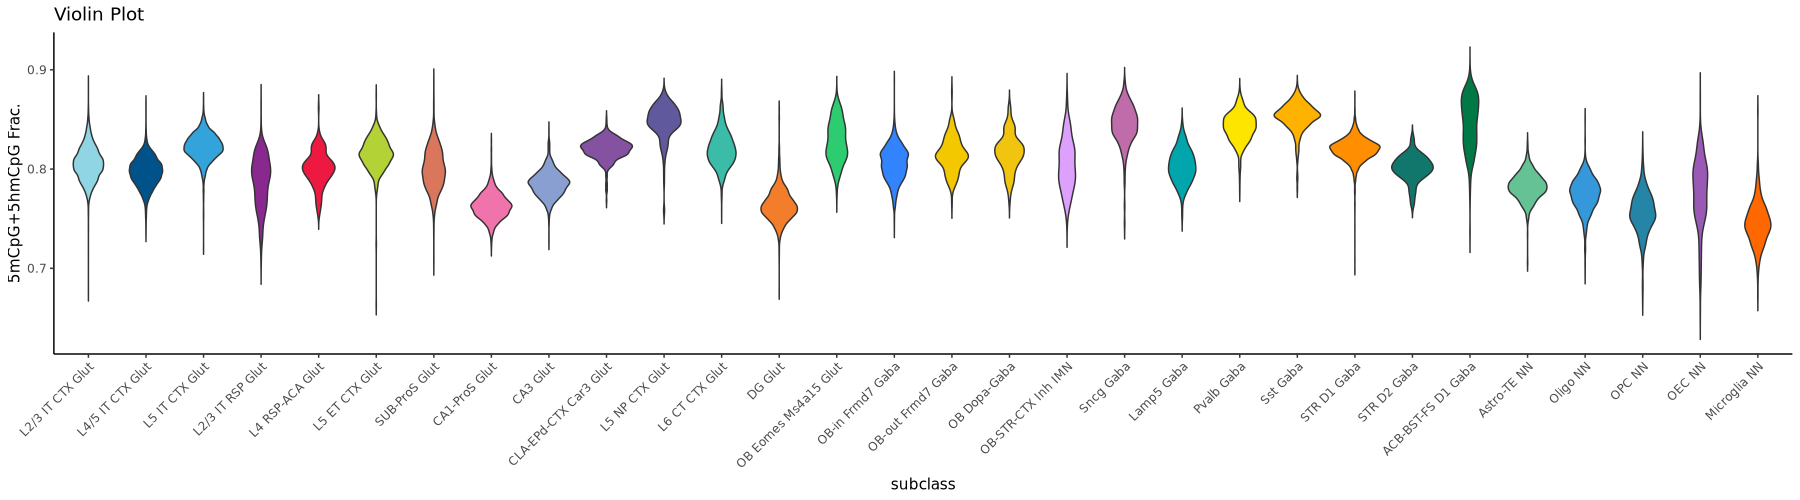

In [57]:
options(repr.plot.width = 18, repr.plot.height = 5, repr.plot.res = 100)
ggplot(mC_hmC_final, aes(x = subclass_label, y = mCpG, fill = subclass_label)) + 
  geom_violin(trim = FALSE) + 
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),legend.position = "none") +
  labs(title = "Violin Plot", 
       x = "subclass", 
       y = "5mCpG+5hmCpG Frac.")

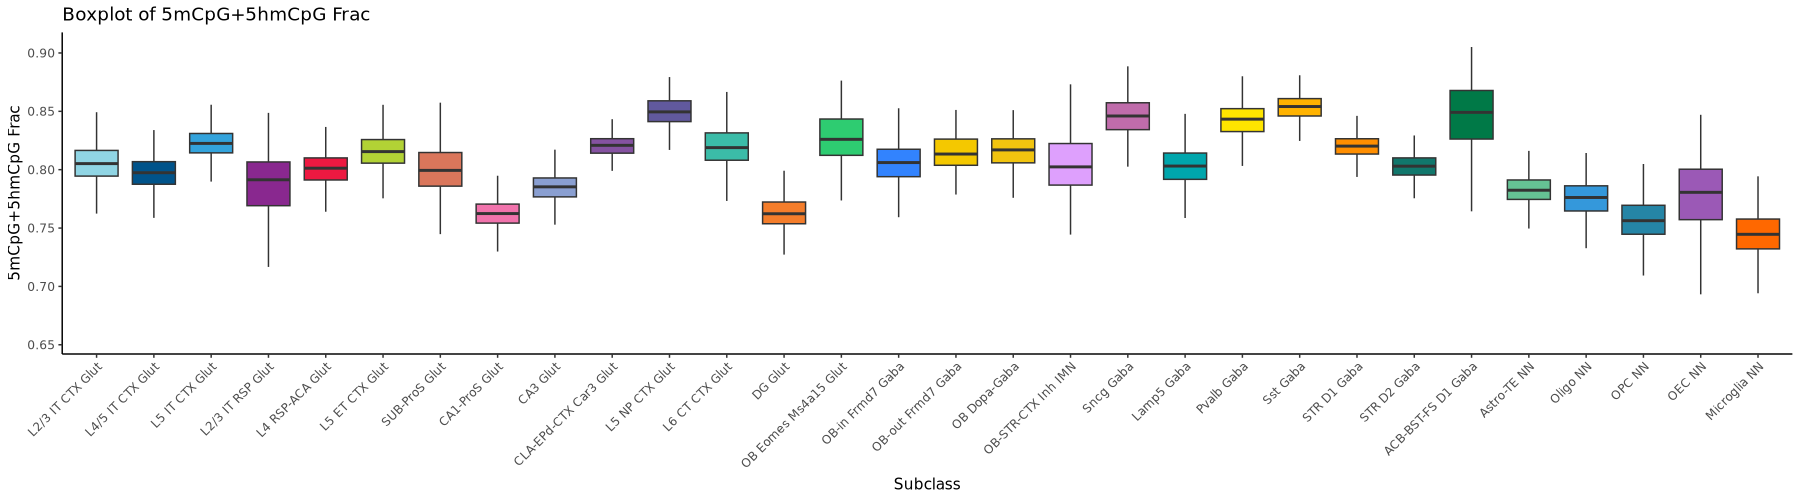

In [58]:
options(repr.plot.width = 18, repr.plot.height = 5, repr.plot.res = 100)
ggplot(mC_hmC_final, aes(x = subclass_label, y = mCpG, fill = subclass_label)) + 
  geom_boxplot(outlier.shape = NA) +
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none") +
  labs(title = "Boxplot of 5mCpG+5hmCpG Frac", 
       x = "Subclass", 
       y = "5mCpG+5hmCpG Frac") 

In [59]:
head(mC_hmC_final);dim(mC_hmC_final)

,Unique_ID,subclass_label,mCpG,hmCpG,true_CpG,mCH,hmCH,true_CH
,<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,P49_Male_LeftCortex_TSO_plate1.AGCCTATC,L2/3 IT CTX Glut,0.806215,0.274885,0.531330,0.0256374,0.00606091,0.01957649
2,P49_Male_LeftCortex_TSO_plate1.AGTGACCT,L2/3 IT CTX Glut,0.790595,0.284005,0.506590,0.0241084,0.00573546,0.01837294
3,P49_Male_LeftCortex_TSO_plate1.ATAACGCC,L2/3 IT CTX Glut,0.771367,0.272256,0.499111,0.0221844,0.00632804,0.01585636
4,P49_Male_LeftCortex_TSO_plate1.ATCTGACC,L2/3 IT CTX Glut,0.779446,0.252037,0.527409,0.0210195,0.00562761,0.01539189
5,P49_Male_LeftCortex_TSO_plate1.CAAGGTAC,L2/3 IT CTX Glut,0.791518,0.242289,0.549229,0.0231378,0.00582872,0.01730908
6,P49_Male_LeftCortex_TSO_plate1.CACAGACT,L2/3 IT CTX Glut,0.779384,0.239272,0.540112,0.0226062,0.00609201,0.01651419


[1] 44608     8

In [60]:
mCpG_filter <- mC_hmC_final %>% dplyr::select(mCpG,subclass_label)
colnames(mCpG_filter) <- c("dna_mCG_R","subclass_label")

hmCpG_filter <- mC_hmC_final %>% dplyr::select(hmCpG,subclass_label)
colnames(hmCpG_filter) <- c("dna_mCG_R","subclass_label")

true_CpG <- mC_hmC_final %>% dplyr::select(true_CpG,subclass_label)
colnames(true_CpG) <- c("dna_mCG_R","subclass_label")

In [61]:
mCH_filter <- mC_hmC_final %>% dplyr::select(mCH,subclass_label)
colnames(mCH_filter) <- c("dna_mCH_R","subclass_label")

hmCH_filter <- mC_hmC_final %>% dplyr::select(hmCH,subclass_label)
colnames(hmCH_filter) <- c("dna_mCH_R","subclass_label")

true_CH <- mC_hmC_final %>% dplyr::select(true_CH,subclass_label)
colnames(true_CH) <- c("dna_mCH_R","subclass_label")

In [62]:
head(mCpG_filter);head(true_CpG);head(hmCpG_filter)
dim(mCpG_filter);dim(true_CpG);dim(hmCpG_filter)

,dna_mCG_R,subclass_label
,<dbl>,<fct>
1,0.806215,L2/3 IT CTX Glut
2,0.790595,L2/3 IT CTX Glut
3,0.771367,L2/3 IT CTX Glut
4,0.779446,L2/3 IT CTX Glut
5,0.791518,L2/3 IT CTX Glut
6,0.779384,L2/3 IT CTX Glut


,dna_mCG_R,subclass_label
,<dbl>,<fct>
1,0.531330,L2/3 IT CTX Glut
2,0.506590,L2/3 IT CTX Glut
3,0.499111,L2/3 IT CTX Glut
4,0.527409,L2/3 IT CTX Glut
5,0.549229,L2/3 IT CTX Glut
6,0.540112,L2/3 IT CTX Glut


,dna_mCG_R,subclass_label
,<dbl>,<fct>
1,0.274885,L2/3 IT CTX Glut
2,0.284005,L2/3 IT CTX Glut
3,0.272256,L2/3 IT CTX Glut
4,0.252037,L2/3 IT CTX Glut
5,0.242289,L2/3 IT CTX Glut
6,0.239272,L2/3 IT CTX Glut


[1] 44608     2

[1] 44608     2

[1] 44608     2

In [63]:
head(mCH_filter);head(true_CH);head(hmCH_filter)
dim(mCH_filter);dim(true_CH);dim(hmCH_filter)

,dna_mCH_R,subclass_label
,<dbl>,<fct>
1,0.0256374,L2/3 IT CTX Glut
2,0.0241084,L2/3 IT CTX Glut
3,0.0221844,L2/3 IT CTX Glut
4,0.0210195,L2/3 IT CTX Glut
5,0.0231378,L2/3 IT CTX Glut
6,0.0226062,L2/3 IT CTX Glut


,dna_mCH_R,subclass_label
,<dbl>,<fct>
1,0.01957649,L2/3 IT CTX Glut
2,0.01837294,L2/3 IT CTX Glut
3,0.01585636,L2/3 IT CTX Glut
4,0.01539189,L2/3 IT CTX Glut
5,0.01730908,L2/3 IT CTX Glut
6,0.01651419,L2/3 IT CTX Glut


,dna_mCH_R,subclass_label
,<dbl>,<fct>
1,0.00606091,L2/3 IT CTX Glut
2,0.00573546,L2/3 IT CTX Glut
3,0.00632804,L2/3 IT CTX Glut
4,0.00562761,L2/3 IT CTX Glut
5,0.00582872,L2/3 IT CTX Glut
6,0.00609201,L2/3 IT CTX Glut


[1] 44608     2

[1] 44608     2

[1] 44608     2

In [64]:
mCpG_filter <- mCpG_filter %>% mutate(group = "5mCpG+5hmCpG")
true_CpG <- true_CpG %>% mutate(group = "5mCpG")
hmCpG_filter <- hmCpG_filter %>% mutate(group = "5hmCpG")

In [65]:
mCH_filter <- mCH_filter %>% mutate(group = "5mCH+5hmCH")
true_CH <- true_CH %>% mutate(group = "5mCH")
hmCH_filter <- hmCH_filter %>% mutate(group = "5hmCH")

In [66]:
head(mCpG_filter);head(true_CpG);head(hmCpG_filter)
dim(mCpG_filter);dim(true_CpG);dim(hmCpG_filter)

,dna_mCG_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.806215,L2/3 IT CTX Glut,5mCpG+5hmCpG
2,0.790595,L2/3 IT CTX Glut,5mCpG+5hmCpG
3,0.771367,L2/3 IT CTX Glut,5mCpG+5hmCpG
4,0.779446,L2/3 IT CTX Glut,5mCpG+5hmCpG
5,0.791518,L2/3 IT CTX Glut,5mCpG+5hmCpG
6,0.779384,L2/3 IT CTX Glut,5mCpG+5hmCpG


,dna_mCG_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.531330,L2/3 IT CTX Glut,5mCpG
2,0.506590,L2/3 IT CTX Glut,5mCpG
3,0.499111,L2/3 IT CTX Glut,5mCpG
4,0.527409,L2/3 IT CTX Glut,5mCpG
5,0.549229,L2/3 IT CTX Glut,5mCpG
6,0.540112,L2/3 IT CTX Glut,5mCpG


,dna_mCG_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.274885,L2/3 IT CTX Glut,5hmCpG
2,0.284005,L2/3 IT CTX Glut,5hmCpG
3,0.272256,L2/3 IT CTX Glut,5hmCpG
4,0.252037,L2/3 IT CTX Glut,5hmCpG
5,0.242289,L2/3 IT CTX Glut,5hmCpG
6,0.239272,L2/3 IT CTX Glut,5hmCpG


[1] 44608     3

[1] 44608     3

[1] 44608     3

In [67]:
head(mCH_filter);head(true_CH);head(hmCH_filter)
dim(mCH_filter);dim(true_CH);dim(hmCH_filter)

,dna_mCH_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.0256374,L2/3 IT CTX Glut,5mCH+5hmCH
2,0.0241084,L2/3 IT CTX Glut,5mCH+5hmCH
3,0.0221844,L2/3 IT CTX Glut,5mCH+5hmCH
4,0.0210195,L2/3 IT CTX Glut,5mCH+5hmCH
5,0.0231378,L2/3 IT CTX Glut,5mCH+5hmCH
6,0.0226062,L2/3 IT CTX Glut,5mCH+5hmCH


,dna_mCH_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.01957649,L2/3 IT CTX Glut,5mCH
2,0.01837294,L2/3 IT CTX Glut,5mCH
3,0.01585636,L2/3 IT CTX Glut,5mCH
4,0.01539189,L2/3 IT CTX Glut,5mCH
5,0.01730908,L2/3 IT CTX Glut,5mCH
6,0.01651419,L2/3 IT CTX Glut,5mCH


,dna_mCH_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.00606091,L2/3 IT CTX Glut,5hmCH
2,0.00573546,L2/3 IT CTX Glut,5hmCH
3,0.00632804,L2/3 IT CTX Glut,5hmCH
4,0.00562761,L2/3 IT CTX Glut,5hmCH
5,0.00582872,L2/3 IT CTX Glut,5hmCH
6,0.00609201,L2/3 IT CTX Glut,5hmCH


[1] 44608     3

[1] 44608     3

[1] 44608     3

In [68]:
combined_data <- rbind(mCpG_filter, true_CpG, hmCpG_filter)
head(combined_data);dim(combined_data)

,dna_mCG_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.806215,L2/3 IT CTX Glut,5mCpG+5hmCpG
2,0.790595,L2/3 IT CTX Glut,5mCpG+5hmCpG
3,0.771367,L2/3 IT CTX Glut,5mCpG+5hmCpG
4,0.779446,L2/3 IT CTX Glut,5mCpG+5hmCpG
5,0.791518,L2/3 IT CTX Glut,5mCpG+5hmCpG
6,0.779384,L2/3 IT CTX Glut,5mCpG+5hmCpG


[1] 133824      3

In [69]:
combined_data2 <- rbind(mCH_filter, true_CH, hmCH_filter)
head(combined_data2);dim(combined_data2)

,dna_mCH_R,subclass_label,group
,<dbl>,<fct>,<chr>
1,0.0256374,L2/3 IT CTX Glut,5mCH+5hmCH
2,0.0241084,L2/3 IT CTX Glut,5mCH+5hmCH
3,0.0221844,L2/3 IT CTX Glut,5mCH+5hmCH
4,0.0210195,L2/3 IT CTX Glut,5mCH+5hmCH
5,0.0231378,L2/3 IT CTX Glut,5mCH+5hmCH
6,0.0226062,L2/3 IT CTX Glut,5mCH+5hmCH


[1] 133824      3

In [70]:
group1.col <- setNames(c("#00AFBB", "#E7B800", "#FC4E07"),unique(combined_data$group))
group1.col
group2.col <- setNames(c("#00AFBB", "#E7B800", "#FC4E07"),unique(combined_data2$group))
group2.col

5mCpG+5hmCpG        5mCpG       5hmCpG 
   "#00AFBB"    "#E7B800"    "#FC4E07"

5mCH+5hmCH       5mCH      5hmCH 
 "#00AFBB"  "#E7B800"  "#FC4E07"

In [71]:
library(ggplot2)
library(gridExtra)


载入程辑包：‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [ ]:
common_margin <- unit(c(1, 1, 1, 2), "mm")
last_plot_margin <- unit(c(1, 1, 1, 2), "mm")

p1 <- ggplot(combined_data %>% filter(group == "5hmCpG"), aes(x = subclass_label, y = dna_mCG_R, fill = subclass_label)) + 
  geom_violin(adjust = 1.5, scale = "width", size = 0.1) +
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  scale_y_continuous(limits = c(0, 0.4), breaks = c(0, 0.4)) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(color = "black", size = 5),
    axis.title.x = element_blank(),
    axis.title.y = element_text(color = "black", size = 5, angle = 90), 
    legend.position = "none",
    plot.margin = common_margin,
    strip.text = element_text(size = 5, color = "black"),
    axis.line = element_line(size = 0.1),
    axis.ticks = element_line(size = 0.1)
  ) +
  labs(y = "5hmCG Frac.",size=5) 

p2 <- ggplot(combined_data %>% filter(group == "5mCpG"), aes(x = subclass_label, y = dna_mCG_R, fill = subclass_label)) + 
  geom_violin(adjust = 1.5, scale = "width", size = 0.1) + 
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  scale_y_continuous(limits = c(0.3, 1), breaks = c(0.3, 1)) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(color = "black", size = 5),
    axis.title.x = element_blank(),
    axis.title.y = element_text(color = "black", size = 5, angle = 90),
    legend.position = "none",
    plot.margin = common_margin,
    strip.text = element_text(size = 5, color = "black"),
    axis.line = element_line(size = 0.1),
    axis.ticks = element_line(size = 0.1)
  ) +
  labs(y = "5mCG Frac.",size=5)


p3 <- ggplot(combined_data %>% filter(group == "5mCpG+5hmCpG"), aes(x = subclass_label, y = dna_mCG_R, fill = subclass_label)) + 
  geom_violin(adjust = 1.5, scale = "width", size = 0.1) + 
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  scale_y_continuous(limits = c(0.3, 1), breaks = c(0.3, 1)) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 5),
    axis.text.y = element_text(color = "black", size = 5),
    axis.title.x = element_text(color = "black", size = 5),
    axis.title.y = element_text(color = "black", size = 5, angle = 90), 
    legend.position = "none",
    plot.margin = last_plot_margin,
    strip.text = element_text(size = 5, color = "black"),
    axis.line = element_line(size = 0.1),
    axis.ticks = element_line(size = 0.1)
  ) +
  labs(y = "5mCG+5hmCG Frac.", x = "Subclass",size=5) 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_ydensity()`).”


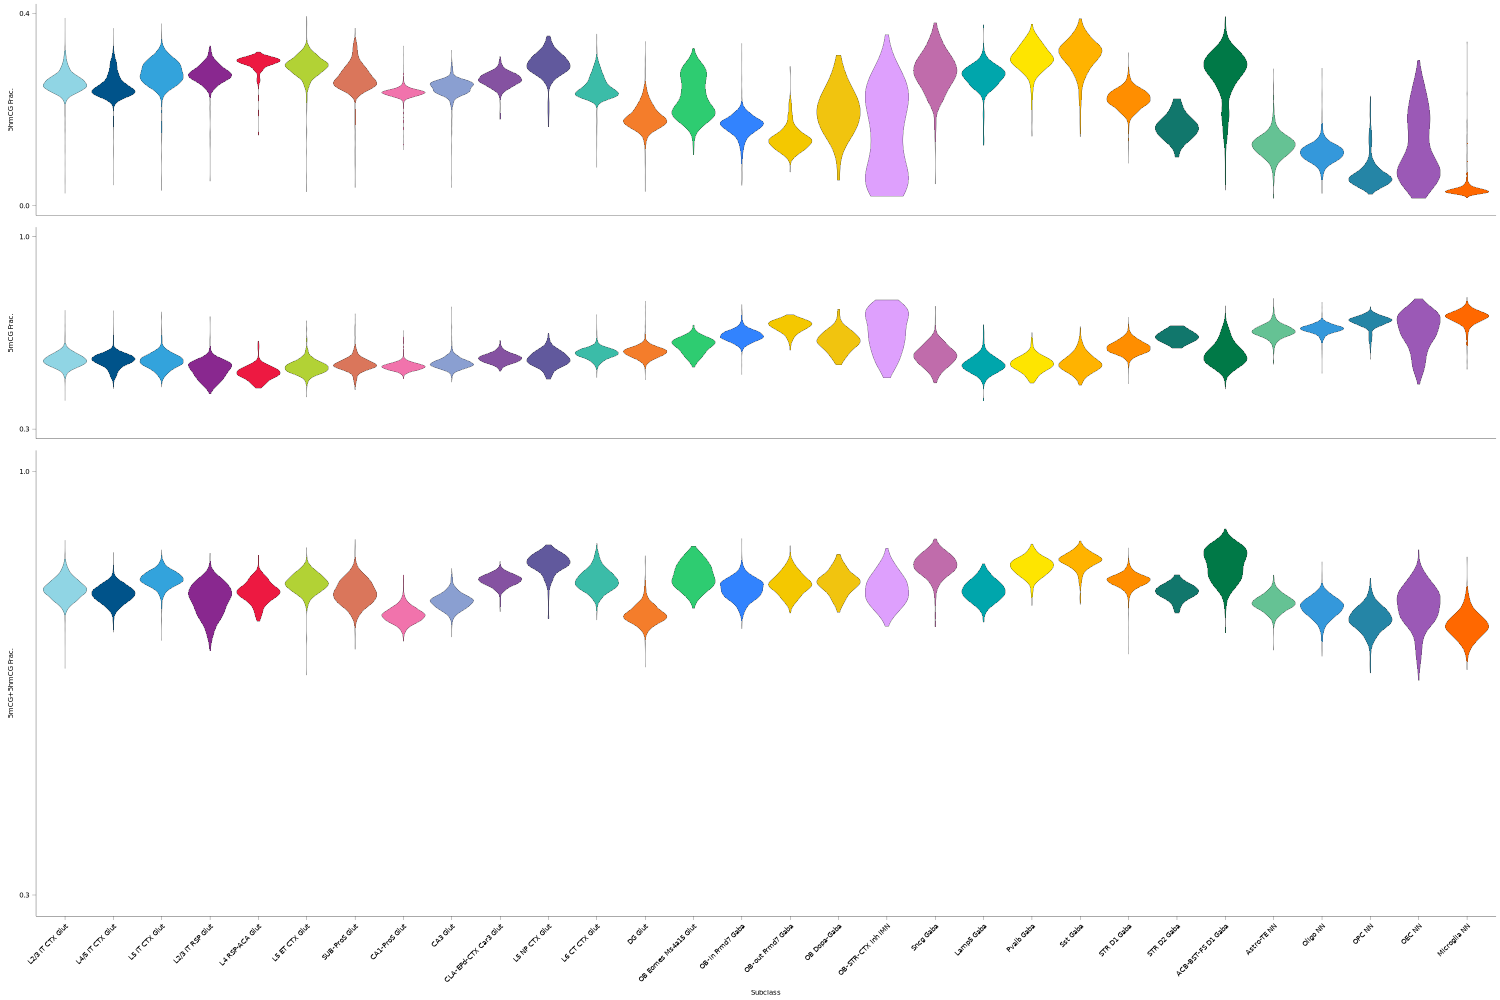

In [73]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
plot_CpG_violinplot_v1 <- grid.arrange(p1, p2, p3, ncol = 1, heights = c(0.1, 0.1, 0.248))

In [ ]:
ggsave(sprintf("%s/01-CpG_ratio_subclass_violinplot_scale_20250206.pdf",outdir), 
       plot_CpG_violinplot_v1, 
       width = 90, height = 60,
       units = "mm")

In [ ]:
common_margin <- unit(c(1, 1, 1, 2), "mm")
last_plot_margin <- unit(c(1, 1, 1, 2), "mm")

p4 <- ggplot(combined_data2 %>% filter(group == "5hmCH"), aes(x = subclass_label, y = dna_mCH_R, fill = subclass_label)) + 
  geom_violin(adjust = 1.5, scale = "width", size = 0.1) +
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  scale_y_continuous(limits = c(0, 0.03), breaks = c(0, 0.03)) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(color = "black", size = 5),
    axis.title.x = element_blank(),
    axis.title.y = element_text(color = "black", size = 5, angle = 90), 
    legend.position = "none",
    plot.margin = common_margin,
    strip.text = element_text(size = 5, color = "black"),
    axis.line = element_line(size = 0.1),
    axis.ticks = element_line(size = 0.1)
  ) +
  labs(y = "5hmCH Frac.",size=5) 

p5 <- ggplot(combined_data2 %>% filter(group == "5mCH"), aes(x = subclass_label, y = dna_mCH_R, fill = subclass_label)) + 
  geom_violin(adjust = 1.5, scale = "width", size = 0.1) + 
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  scale_y_continuous(limits = c(0, 0.03), breaks = c(0, 0.03)) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.text.y = element_text(color = "black", size = 5),
    axis.title.x = element_blank(),
    axis.title.y = element_text(color = "black", size = 5, angle = 90),
    legend.position = "none",
    plot.margin = common_margin,
    strip.text = element_text(size = 5, color = "black"),
    axis.line = element_line(size = 0.1),
    axis.ticks = element_line(size = 0.1)
  ) +
  labs(y = "5mCH Frac.",size=5) 

p6 <- ggplot(combined_data2 %>% filter(group == "5mCH+5hmCH"), aes(x = subclass_label, y = dna_mCH_R, fill = subclass_label)) + 
  geom_violin(adjust = 1.5, scale = "width", size = 0.1) + 
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  scale_y_continuous(limits = c(0, 0.03), breaks = c(0, 0.03)) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 5),
    axis.text.y = element_text(color = "black", size = 5),
    axis.title.x = element_text(color = "black", size = 5),
    axis.title.y = element_text(color = "black", size = 5, angle = 90), 
    legend.position = "none",
    plot.margin = last_plot_margin,
    strip.text = element_text(size = 5, color = "black"),
    axis.line = element_line(size = 0.1),
    axis.ticks = element_line(size = 0.1)
  ) +
  labs(y = "5mCH+5hmCH Frac.", x = "Subclass",size=5) 

Warning message:
“Removed 5 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 852 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 3732 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


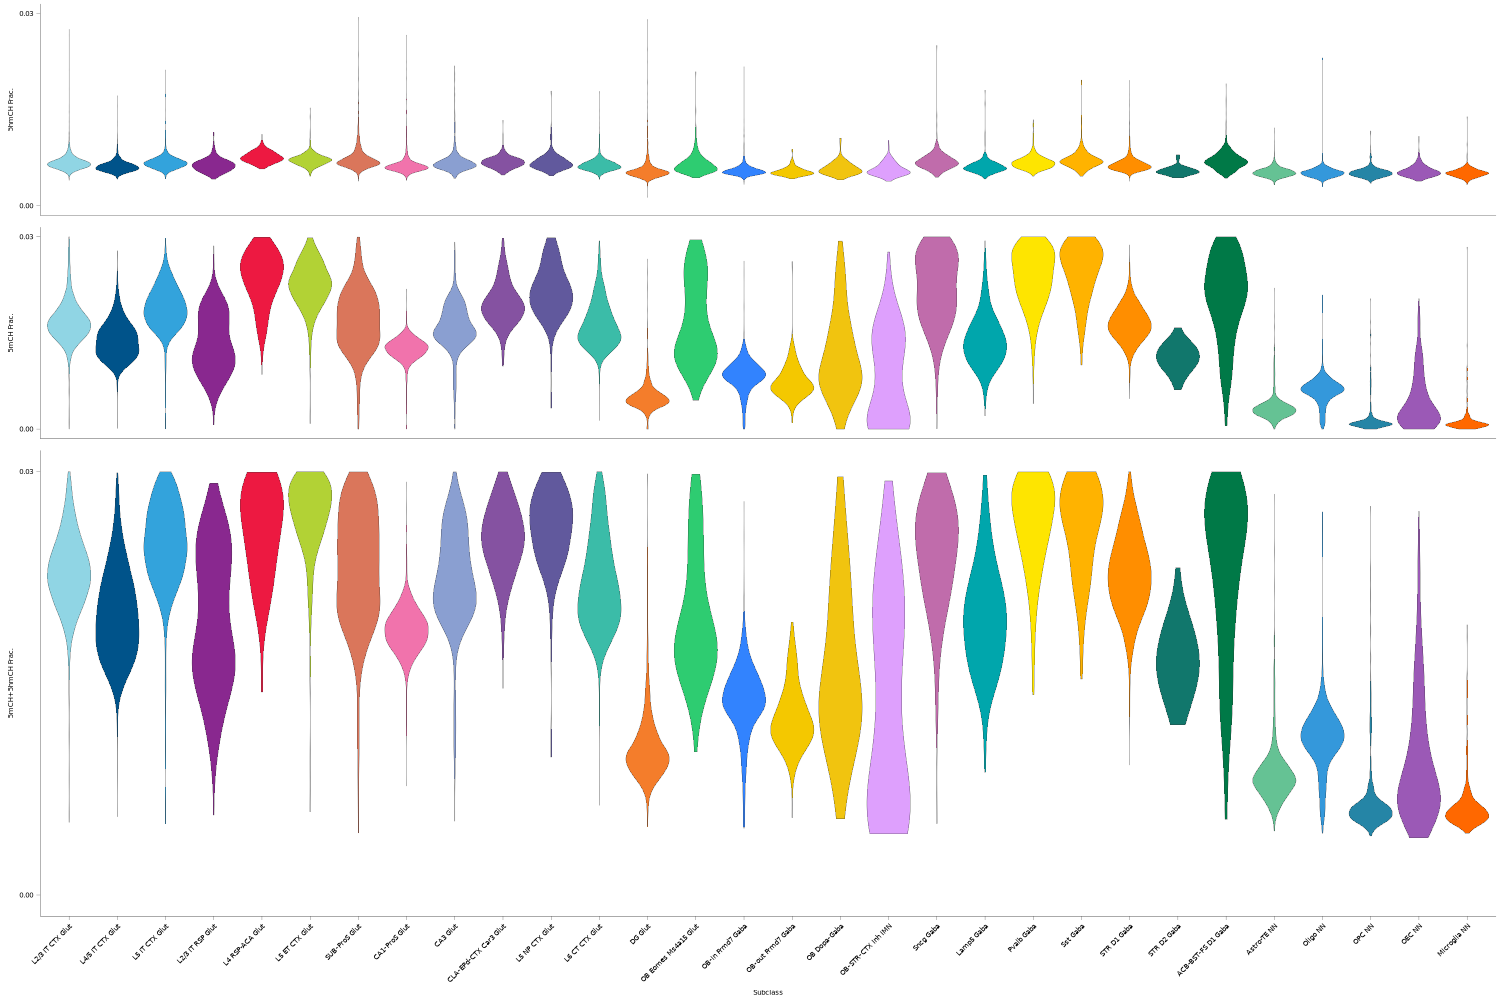

In [76]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
plot_CpG_violinplot_v2 <- grid.arrange(p4, p5, p6, ncol = 1, heights = c(0.1, 0.1, 0.248))

In [ ]:
ggsave(sprintf("%s/01-CH_ratio_subclass_violinplot_scale_20250206.pdf",outdir), 
       plot_CpG_violinplot_v2, 
       width = 90, height = 60,
       units = "mm")

In [ ]:
#### 下面的内容不用管了

In [80]:
pic_mCpG_combined <- ggplot(combined_data, aes(x = subclass_label, y = dna_mCG_R, fill = group)) + 
  geom_boxplot(outlier.shape = NA) +
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = group.col) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 14),
    axis.text.y = element_text(color = "black", size = 14),
    axis.title.x = element_text(color = "black", size = 16),
    axis.title.y = element_text(color = "black", size = 16),
    plot.title = element_text(size = 20, hjust = 0.5),
    legend.position = "none",
    plot.margin = unit(c(1.5, 1.5, 1.5, 1.5), "cm"),
    strip.text = element_text(size = 16, color = "black")
  ) +
  labs(title = "Boxplot of CpG Frac Across Group", 
       x = "Subclass", 
       y = "CpG Frac") +
  facet_grid(rows = vars(group), scales = "free_y")

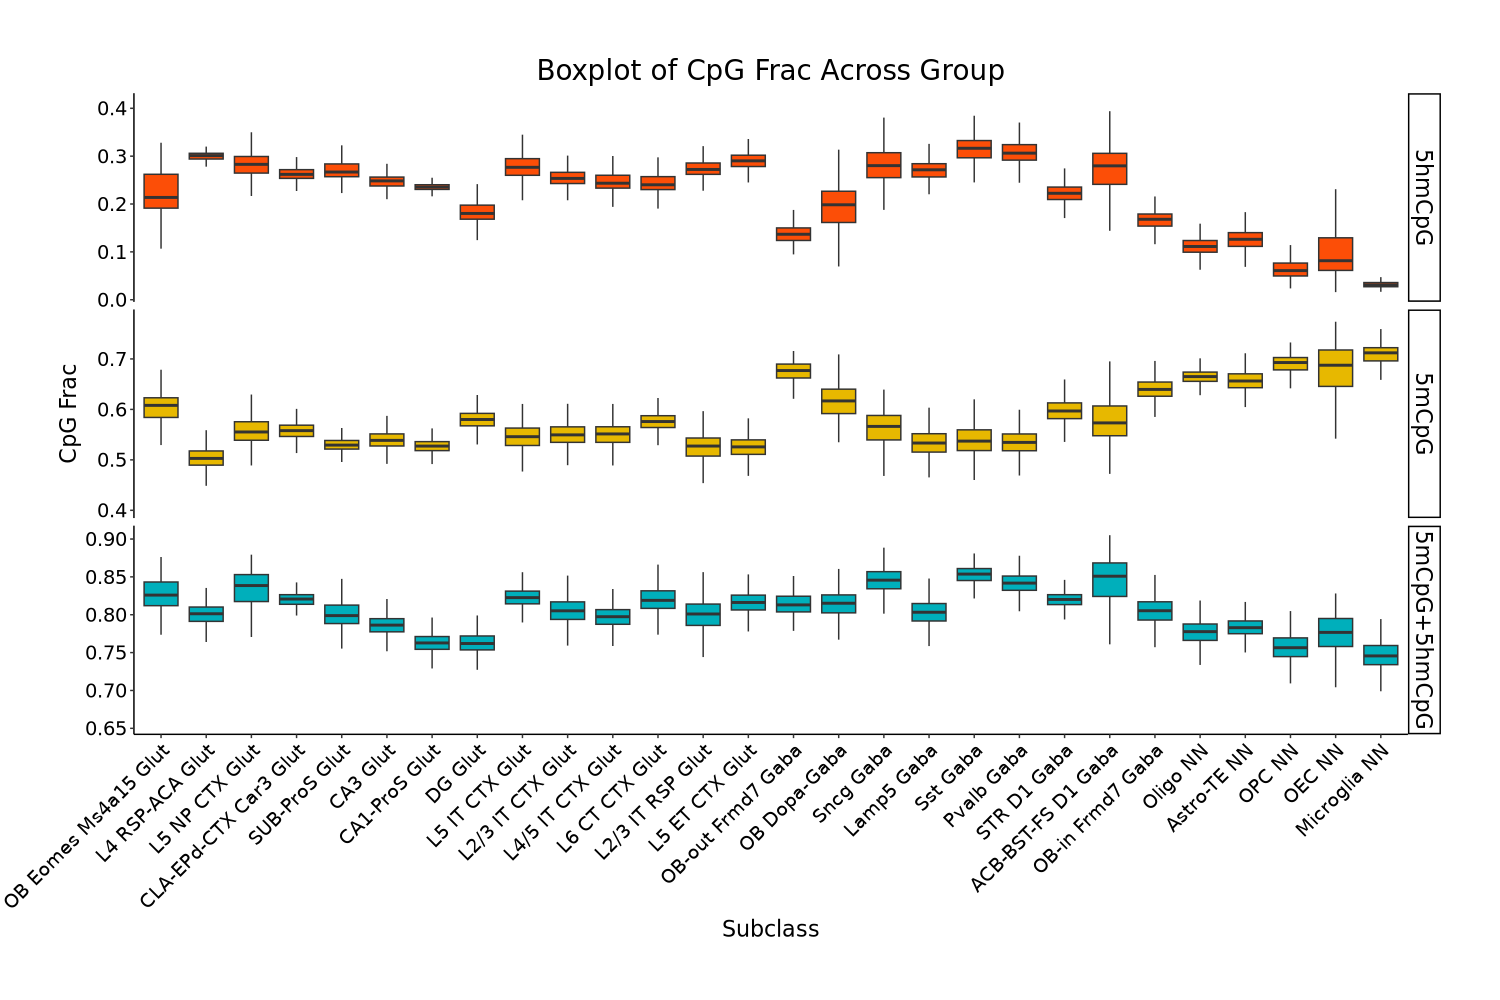

In [81]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
pic_mCpG_combined

In [ ]:
pdf(sprintf("%s/08-CpG_ratio_subclass_boxplot_v1.pdf",outdir),width = 15,height = 10)
pic_mCpG_combined
dev.off()

png 
  2

In [83]:
pic_mCpG_combined_v2 <- ggplot(combined_data, aes(x = subclass_label, y = dna_mCG_R, fill = subclass_label)) + 
  geom_boxplot(outlier.shape = NA) +
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 14),
    axis.text.y = element_text(color = "black", size = 14),
    axis.title.x = element_text(color = "black", size = 16),
    axis.title.y = element_text(color = "black", size = 16),
    plot.title = element_text(size = 20, hjust = 0.5),
    legend.position = "none",
    plot.margin = unit(c(1.5, 1.5, 1.5, 1.5), "cm"),
    strip.text = element_text(size = 16, color = "black")
  ) +
  labs(title = "Boxplot of CpG Frac Across Group", 
       x = "Subclass", 
       y = "CpG Frac") +
  facet_grid(rows = vars(group), scales = "free_y")

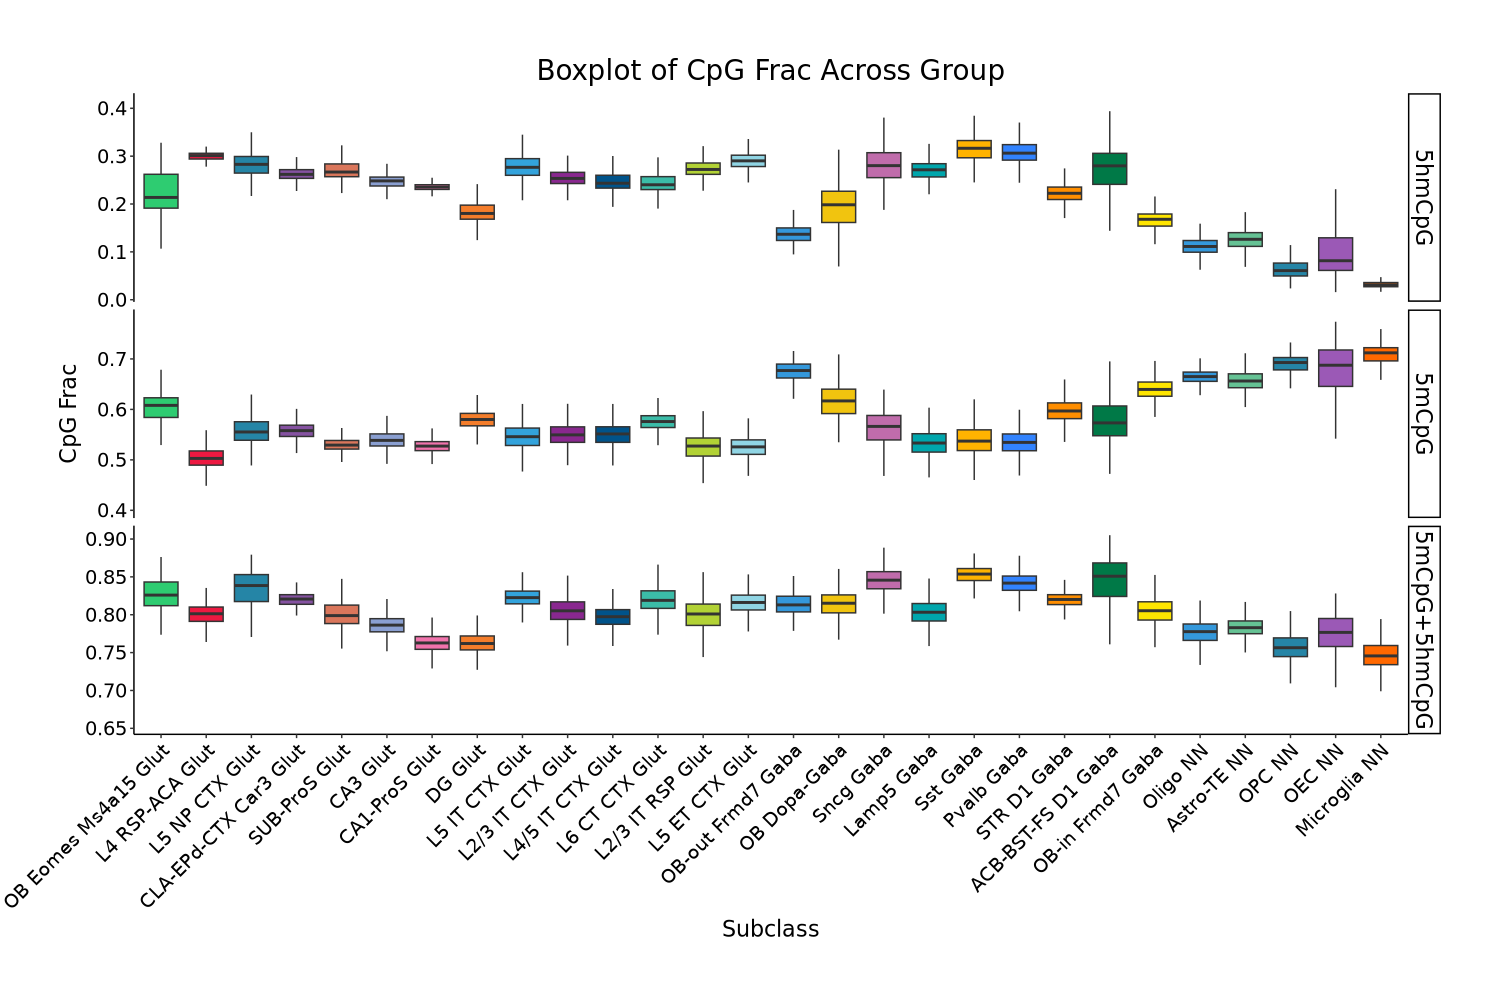

In [84]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
pic_mCpG_combined_v2

In [ ]:
pdf(sprintf("%s/08-CpG_ratio_subclass_boxplot_v2.pdf",outdir),width = 15,height = 10)
pic_mCpG_combined_v2
dev.off()

png 
  2

In [ ]:
pic_mCpG_violin2 <- ggplot(combined_data, aes(x = subclass_label, y = dna_mCG_R, fill = subclass_label)) + 
  geom_violin(adjust = 1.5, scale = "width") + 
  theme_minimal() +
  theme_classic() +
  scale_fill_manual(values = subclass_label.col) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 14),
    axis.text.y = element_text(color = "black", size = 14),
    axis.title.x = element_text(color = "black", size = 16),
    axis.title.y = element_text(color = "black", size = 16),
    plot.title = element_text(size = 20, hjust = 0.5),
    legend.position = "none",
    plot.margin = unit(c(1.5, 1.5, 1.5, 1.5), "cm"),
    strip.text = element_text(size = 16, color = "black")
  ) +
  labs(title = "Violin Plot of CpG Frac Across Group", 
       x = "Subclass", 
       y = "CpG Frac") +
  facet_grid(rows = vars(group), scales = "free_y")

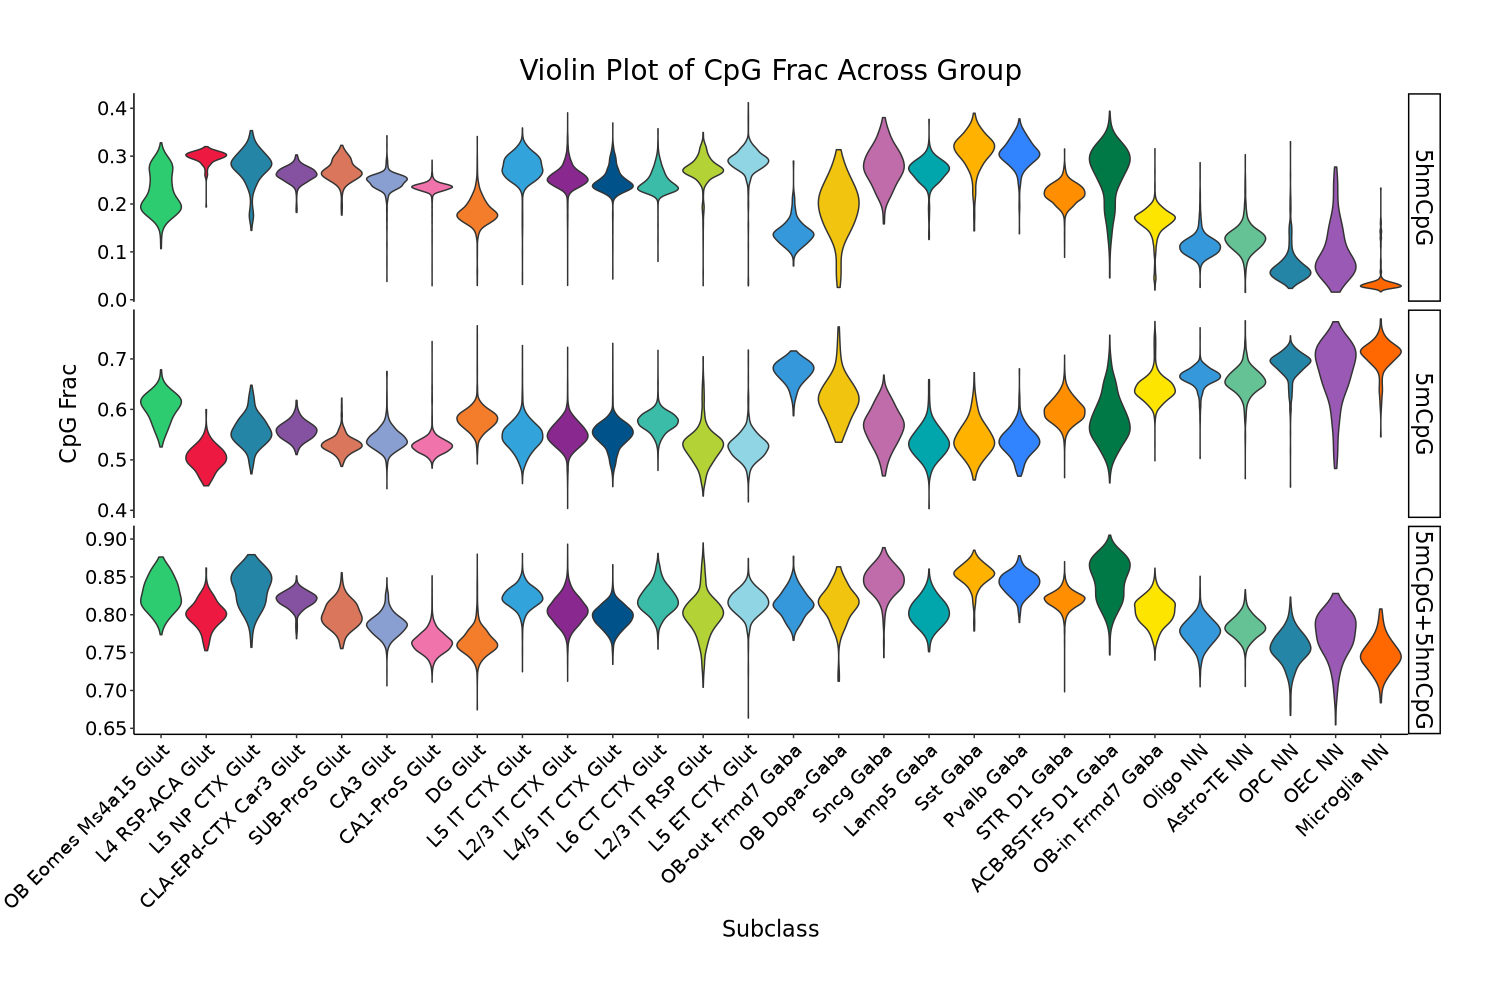

In [87]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
pic_mCpG_violin2

In [ ]:
pic_mCpG_violin1 <- ggplot(combined_data, aes(x = subclass_label, y = dna_mCG_R, fill = group)) + 
  geom_violin(adjust = 1.5, scale = "width") + 
  theme_classic() +
  scale_fill_manual(values = group.col) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 14),
    axis.text.y = element_text(color = "black", size = 14),
    axis.title.x = element_text(color = "black", size = 16),
    axis.title.y = element_text(color = "black", size = 16),
    plot.title = element_text(size = 20, hjust = 0.5),
    legend.position = "none",
    plot.margin = unit(c(1.5, 1.5, 1.5, 1.5), "cm"),
    strip.text = element_text(size = 16, color = "black")
  ) +
  labs(title = "Boxplot of CpG Frac Across Group", 
       x = "Subclass", 
       y = "CpG Frac") +
  facet_grid(rows = vars(group), scales = "free_y")

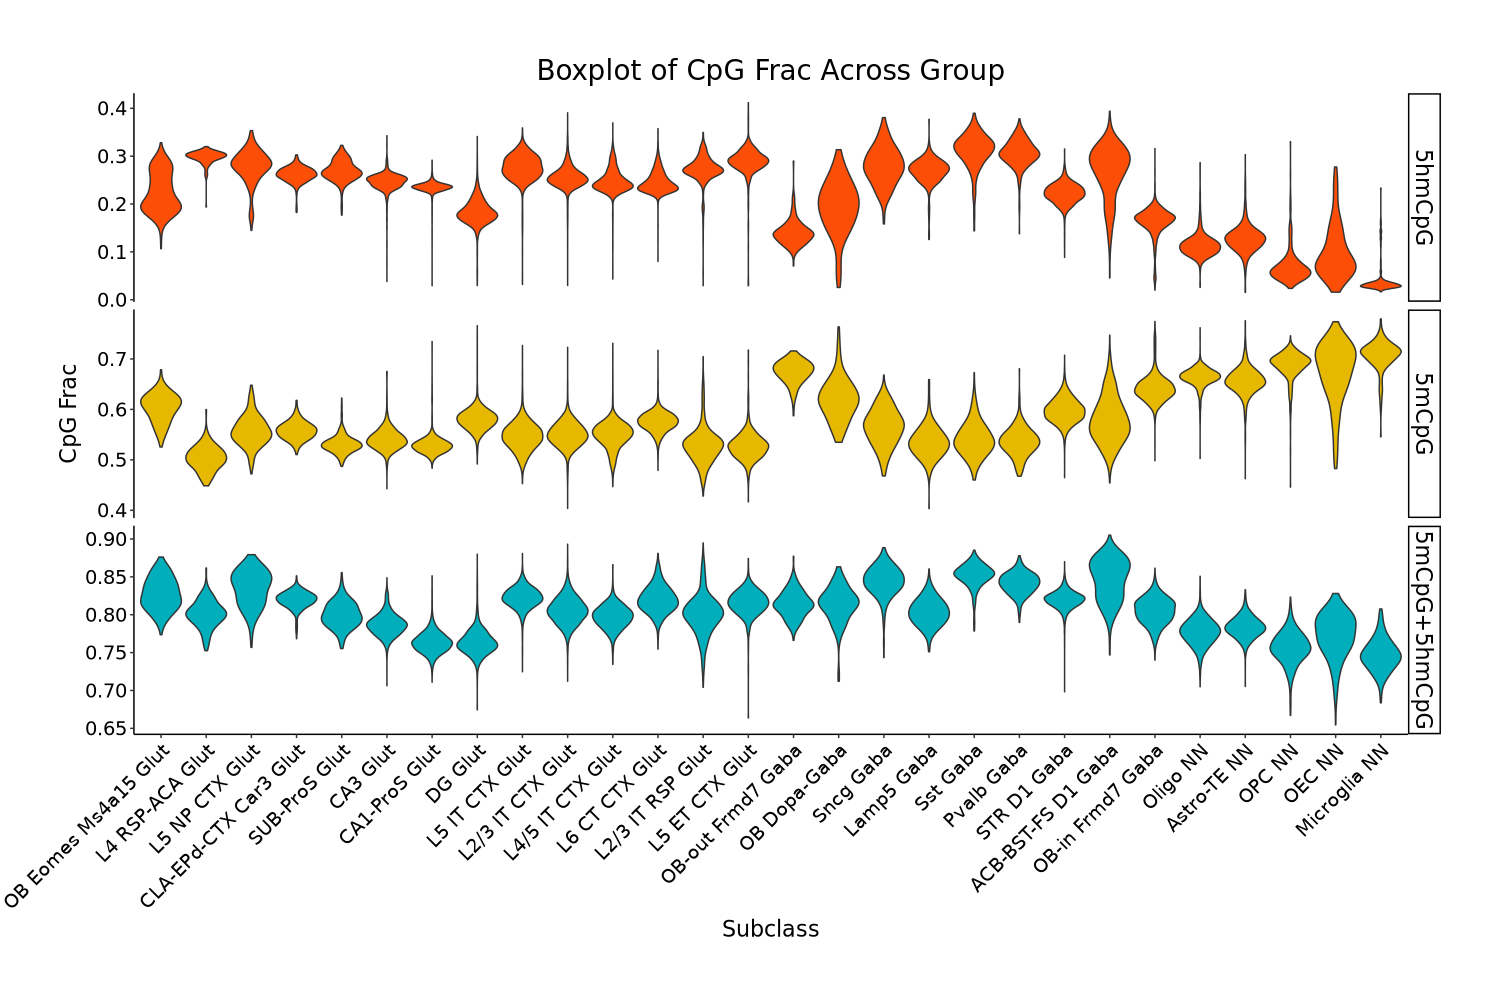

In [89]:
options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 100)
pic_mCpG_violin1

In [ ]:
pdf(sprintf("%s/08-CpG_ratio_subclass_violinplot_v1.pdf",outdir),width = 15,height = 10)
pic_mCpG_violin1
dev.off()

png 
  2

In [ ]:
pdf(sprintf("%s/08-CpG_ratio_subclass_violinplot_v2.pdf",outdir),width = 15,height = 10)
pic_mCpG_violin2
dev.off()

png 
  2